
# Personalized PageRank për materiale kursi

**Student:** Donald Shtjefni  
**Lënda:** Modelim në Fizikë  
**Tema:** Personalized PageRank për një rrjet materialesh kursi dhe preferencash tematike

Në këtë notebook ndërtohet një shembull i thjeshtë i Personalized PageRank. Ideja është të renditen materialet e kursit jo vetëm nga lidhjet që kanë me njëra-tjetrën, por edhe nga tema që zgjedh studenti.

Temat që përdorim këtu janë: `ODE`, `kaos`, `epidemi`, `trafik`, `algoritme`.



## 1. Ideja e modelit

Çdo material kursi e trajtojmë si një **nyje** të një grafi. Nëse një material lidhet konceptualisht me një material tjetër, vendosim një lidhje të drejtuar.

Shembull: nëse një notebook për ODE ndihmon për të kuptuar sistemet kaotike, atëherë krijojmë një lidhje nga materiali i ODE drejt materialit të kaosit.

Formula bazë është:

$$
p^{(k+1)} = \alpha M p^{(k)} + (1-\alpha)v
$$

ku:

- $M$ është matrica e kalimit të grafit;
- $\alpha$ është faktori i amortizimit;
- $v$ është vektori i personalizimit;
- $p$ është vektori i renditjes.

Nëse $v$ është uniform, marrim PageRank klasik. Nëse $v$ favorizon një temë të caktuar, marrim Personalized PageRank.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)



## 2. Ndërtimi i dataset-it

Dataset-i është i vogël dhe demonstrativ. Ai përfaqëson disa materiale të kursit: hyrje, ODE, kaos, epidemi, trafik dhe algoritme renditjeje.

Secili material ka edhe një etiketë tematike. Këto etiketa do të përdoren më vonë për të ndërtuar vektorët tematikë.


In [2]:

materials = [
    {'id': 'intro', 'title': 'Hyrje në modelim numerik', 'topic': 'ODE'},
    {'id': 'ode', 'title': 'Ekuacione diferenciale ODE', 'topic': 'ODE'},
    {'id': 'sir', 'title': 'Modeli SIR epidemik', 'topic': 'epidemi'},
    {'id': 'traffic', 'title': 'Model i thjeshtë trafiku', 'topic': 'trafik'},
    {'id': 'lorenz', 'title': 'Sistemi Lorenz dhe kaosi', 'topic': 'kaos'},
    {'id': 'rossler', 'title': 'Sistemi Rössler', 'topic': 'kaos'},
    {'id': 'pagerank', 'title': 'PageRank klasik', 'topic': 'algoritme'},
    {'id': 'personalized', 'title': 'Personalized PageRank', 'topic': 'algoritme'},
    {'id': 'project_sir', 'title': 'Projekt SIR hapësinor', 'topic': 'epidemi'},
    {'id': 'project_rank', 'title': 'Projekt renditje tematike', 'topic': 'algoritme'},
]

nodes = [m['id'] for m in materials]
labels = {m['id']: m['title'] for m in materials}
topics = {m['id']: m['topic'] for m in materials}

pd.DataFrame(materials)


,id,title,topic
0,intro,Hyrje në modelim numerik,ODE
1,ode,Ekuacione diferenciale ODE,ODE
2,sir,Modeli SIR epidemik,epidemi
3,traffic,Model i thjeshtë trafiku,trafik
4,lorenz,Sistemi Lorenz dhe kaosi,kaos
5,rossler,Sistemi Rössler,kaos
6,pagerank,PageRank klasik,algoritme
7,personalized,Personalized PageRank,algoritme
8,project_sir,Projekt SIR hapësinor,epidemi
9,project_rank,Projekt renditje tematike,algoritme



## 3. Lidhjet konceptuale

Lidhjet janë vendosur në mënyrë të arsyeshme për një kurs modelimi. Për shembull:

- hyrja lidhet me ODE;
- ODE lidhet me modele epidemike, trafik dhe kaos;
- PageRank lidhet me Personalized PageRank;
- Personalized PageRank lidhet me projektin e renditjes tematike.

Kjo nuk është një databazë reale e madhe, por një model i vogël që na lejon të kuptojmë algoritmin.


In [3]:

edges = [
    ('intro', 'ode'),
    ('ode', 'sir'),
    ('ode', 'traffic'),
    ('ode', 'lorenz'),
    ('lorenz', 'rossler'),
    ('sir', 'project_sir'),
    ('traffic', 'sir'),
    ('pagerank', 'personalized'),
    ('personalized', 'project_rank'),
    ('project_rank', 'pagerank'),
    ('intro', 'pagerank'),
    ('pagerank', 'project_rank'),
    ('project_sir', 'sir'),
    ('rossler', 'lorenz'),
]

edges


[('intro', 'ode'),
 ('ode', 'sir'),
 ('ode', 'traffic'),
 ('ode', 'lorenz'),
 ('lorenz', 'rossler'),
 ('sir', 'project_sir'),
 ('traffic', 'sir'),
 ('pagerank', 'personalized'),
 ('personalized', 'project_rank'),
 ('project_rank', 'pagerank'),
 ('intro', 'pagerank'),
 ('pagerank', 'project_rank'),
 ('project_sir', 'sir'),
 ('rossler', 'lorenz')]


## 4. Matrica e kalimit

Tani ndërtojmë matricën $M$. Kolona tregon nyjen nga ku nisemi, ndërsa rreshti tregon nyjen ku shkojmë.

Nëse një nyje ka disa dalje, probabiliteti ndahet në mënyrë të barabartë midis tyre.


In [4]:

def build_transition_matrix(nodes, edges):
    n = len(nodes)
    index = {node: i for i, node in enumerate(nodes)}
    M = np.zeros((n, n))
    
    out_links = {node: [] for node in nodes}
    for source, target in edges:
        out_links[source].append(target)
    
    for source in nodes:
        j = index[source]
        targets = out_links[source]
        
        if len(targets) == 0:
            # nëse nyja nuk ka dalje, shpërndajmë në mënyrë uniforme
            M[:, j] = 1 / n
        else:
            for target in targets:
                i = index[target]
                M[i, j] = 1 / len(targets)
    
    return M

M = build_transition_matrix(nodes, edges)
M_df = pd.DataFrame(M, index=nodes, columns=nodes)
M_df


,intro,ode,sir,traffic,lorenz,rossler,pagerank,personalized,project_sir,project_rank
intro,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ode,0.5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sir,0.0,0.333333,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
traffic,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
lorenz,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
rossler,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
pagerank,0.5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
personalized,0.0,0.000000,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0
project_sir,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
project_rank,0.0,0.000000,0.0,0.0,0.0,0.0,0.5,1.0,0.0,0.0



## 5. Implementimi i PageRank

Përdorim metodën e iterimit. Fillojmë me një shpërndarje uniforme dhe e përditësojmë derisa ndryshimi të bëhet shumë i vogël.


In [5]:

def pagerank(M, alpha=0.85, v=None, max_iter=100, tol=1e-8):
    n = M.shape[0]
    p = np.ones(n) / n
    
    if v is None:
        v = np.ones(n) / n
    else:
        v = np.array(v, dtype=float)
        v = v / v.sum()
    
    history = []
    
    for k in range(max_iter):
        p_new = alpha * M @ p + (1 - alpha) * v
        diff = np.linalg.norm(p_new - p, 1)
        history.append(diff)
        
        p = p_new
        if diff < tol:
            break
    
    return p, history



## 6. PageRank klasik

Në fillim përdorim vektor uniform. Kjo do të thotë se algoritmi nuk favorizon asnjë temë të veçantë.


In [6]:

pr_uniform, hist_uniform = pagerank(M, alpha=0.85)

ranking_uniform = pd.DataFrame({
    'material': nodes,
    'titulli': [labels[n] for n in nodes],
    'tema': [topics[n] for n in nodes],
    'pagerank': pr_uniform
}).sort_values('pagerank', ascending=False)

ranking_uniform


,material,titulli,tema,pagerank
2,sir,Modeli SIR epidemik,epidemi,0.186321
8,project_sir,Projekt SIR hapësinor,epidemi,0.173373
6,pagerank,PageRank klasik,algoritme,0.135557
9,project_rank,Projekt renditje tematike,algoritme,0.134332
4,lorenz,Sistemi Lorenz dhe kaosi,kaos,0.121824
5,rossler,Sistemi Rössler,kaos,0.118551
7,personalized,Personalized PageRank,algoritme,0.072612
1,ode,Ekuacione diferenciale ODE,ODE,0.021375
3,traffic,Model i thjeshtë trafiku,trafik,0.021056
0,intro,Hyrje në modelim numerik,ODE,0.015000


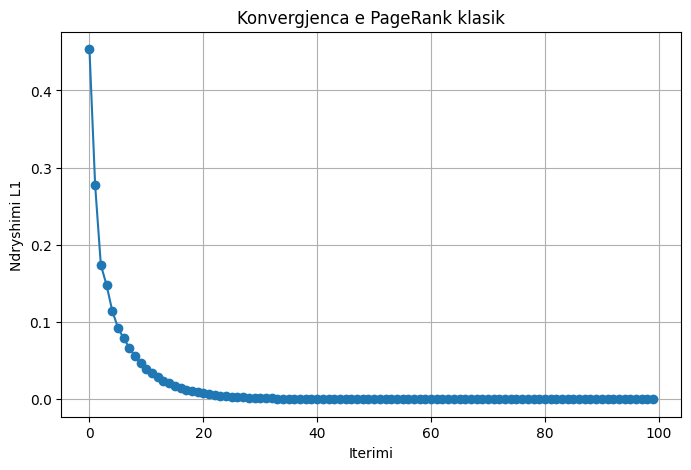

In [7]:

plt.plot(hist_uniform, marker='o')
plt.xlabel('Iterimi')
plt.ylabel('Ndryshimi L1')
plt.title('Konvergjenca e PageRank klasik')
plt.grid(True)
plt.show()



## 7. Vektorët tematikë

Kjo është pjesa kryesore e personalizimit. Për një temë të zgjedhur, u japim peshë më të madhe materialeve që kanë atë temë.

Për shembull, nëse tema është `kaos`, atëherë materialet `lorenz` dhe `rossler` marrin peshë më të madhe në vektorin $v$.


In [8]:

def topic_vector(nodes, topics, selected_topic):
    n = len(nodes)
    v = np.zeros(n)
    
    for i, node in enumerate(nodes):
        if topics[node] == selected_topic:
            v[i] = 1
    
    # nëse tema nuk gjendet, përdorim vektor uniform
    if v.sum() == 0:
        v = np.ones(n)
    
    return v / v.sum()

v_kaos = topic_vector(nodes, topics, 'kaos')
pd.DataFrame({'material': nodes, 'tema': [topics[n] for n in nodes], 'v_kaos': v_kaos})


,material,tema,v_kaos
0,intro,ODE,0.0
1,ode,ODE,0.0
2,sir,epidemi,0.0
3,traffic,trafik,0.0
4,lorenz,kaos,0.5
5,rossler,kaos,0.5
6,pagerank,algoritme,0.0
7,personalized,algoritme,0.0
8,project_sir,epidemi,0.0
9,project_rank,algoritme,0.0



## 8. Personalized PageRank për tema të ndryshme

Tani llogarisim renditjen për disa tema. Kjo na lejon të shohim se si ndryshon rezultati kur ndryshon interesi i studentit.


In [9]:

def ranking_for_topic(selected_topic):
    v = topic_vector(nodes, topics, selected_topic)
    scores, history = pagerank(M, alpha=0.85, v=v)
    table = pd.DataFrame({
        'material': nodes,
        'titulli': [labels[n] for n in nodes],
        'tema': [topics[n] for n in nodes],
        'score': scores
    }).sort_values('score', ascending=False)
    return table, history

ranking_kaos, hist_kaos = ranking_for_topic('kaos')
ranking_epidemi, hist_epidemi = ranking_for_topic('epidemi')
ranking_algoritme, hist_algoritme = ranking_for_topic('algoritme')

ranking_kaos


,material,titulli,tema,score
5,rossler,Sistemi Rössler,kaos,5.000000e-01
4,lorenz,Sistemi Lorenz dhe kaosi,kaos,5.000000e-01
8,project_sir,Projekt SIR hapësinor,epidemi,2.186918e-08
2,sir,Modeli SIR epidemik,epidemi,1.312151e-08
6,pagerank,PageRank klasik,algoritme,1.224674e-08
9,project_rank,Projekt renditje tematike,algoritme,1.224674e-08
7,personalized,Personalized PageRank,algoritme,6.123372e-09
0,intro,Hyrje në modelim numerik,ODE,0.000000e+00
1,ode,Ekuacione diferenciale ODE,ODE,0.000000e+00
3,traffic,Model i thjeshtë trafiku,trafik,0.000000e+00


In [10]:

ranking_epidemi


,material,titulli,tema,score
8,project_sir,Projekt SIR hapësinor,epidemi,5.000000e-01
2,sir,Modeli SIR epidemik,epidemi,5.000000e-01
6,pagerank,PageRank klasik,algoritme,1.224674e-08
9,project_rank,Projekt renditje tematike,algoritme,1.224674e-08
5,rossler,Sistemi Rössler,kaos,1.166356e-08
4,lorenz,Sistemi Lorenz dhe kaosi,kaos,1.020562e-08
7,personalized,Personalized PageRank,algoritme,6.123372e-09
0,intro,Hyrje në modelim numerik,ODE,0.000000e+00
1,ode,Ekuacione diferenciale ODE,ODE,0.000000e+00
3,traffic,Model i thjeshtë trafiku,trafik,0.000000e+00


In [11]:

ranking_algoritme


,material,titulli,tema,score
9,project_rank,Projekt renditje tematike,algoritme,3.973996e-01
6,pagerank,PageRank klasik,algoritme,3.877897e-01
7,personalized,Personalized PageRank,algoritme,2.148106e-01
8,project_sir,Projekt SIR hapësinor,epidemi,2.186918e-08
2,sir,Modeli SIR epidemik,epidemi,1.312151e-08
5,rossler,Sistemi Rössler,kaos,1.166356e-08
4,lorenz,Sistemi Lorenz dhe kaosi,kaos,1.020562e-08
0,intro,Hyrje në modelim numerik,ODE,0.000000e+00
1,ode,Ekuacione diferenciale ODE,ODE,0.000000e+00
3,traffic,Model i thjeshtë trafiku,trafik,0.000000e+00



## 9. Krahasimi grafik i renditjeve

Këtu krahasojmë PageRank klasik me Personalized PageRank për një temë të zgjedhur.


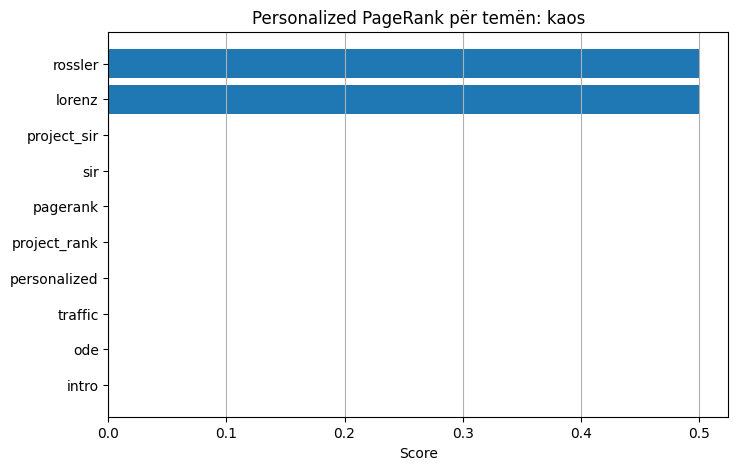

In [12]:

def plot_ranking(table, title):
    table_sorted = table.sort_values('score')
    plt.barh(table_sorted['material'], table_sorted['score'])
    plt.xlabel('Score')
    plt.title(title)
    plt.grid(axis='x')
    plt.show()

plot_ranking(ranking_kaos, 'Personalized PageRank për temën: kaos')


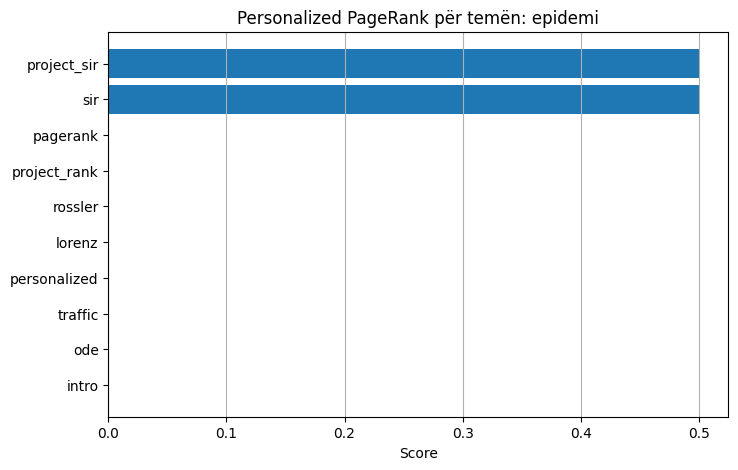

In [13]:

plot_ranking(ranking_epidemi, 'Personalized PageRank për temën: epidemi')


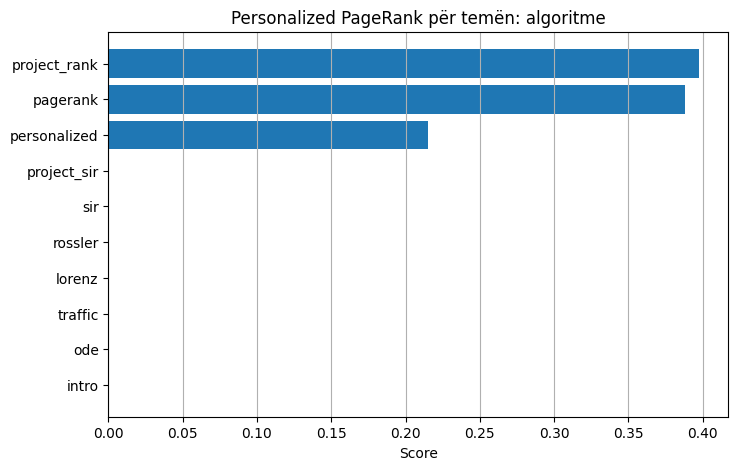

In [14]:

plot_ranking(ranking_algoritme, 'Personalized PageRank për temën: algoritme')



## 10. Krahasimi i tre temave në një tabelë

Kjo tabelë tregon se cilat materiale dalin të parat për secilën temë.


In [15]:

comparison = pd.DataFrame({
    'kaos': ranking_kaos['material'].head(5).values,
    'epidemi': ranking_epidemi['material'].head(5).values,
    'algoritme': ranking_algoritme['material'].head(5).values
})

comparison


,kaos,epidemi,algoritme
0,rossler,project_sir,project_rank
1,lorenz,sir,pagerank
2,project_sir,pagerank,personalized
3,sir,project_rank,project_sir
4,pagerank,rossler,sir



## 11. Analizë e shkurtër

Nga rezultatet vërehet se:

- Kur zgjedhim temën `kaos`, në krye dalin materialet që lidhen me Lorenz dhe Rössler.
- Kur zgjedhim temën `epidemi`, favorizohen materiali SIR dhe projekti SIR.
- Kur zgjedhim temën `algoritme`, favorizohen PageRank, Personalized PageRank dhe projekti i renditjes tematike.

Kjo tregon se vektori i personalizimit $v$ ndikon realisht në renditje. Pra, algoritmi nuk jep një renditje të vetme për të gjithë, por e ndryshon renditjen sipas temës së zgjedhur.



## 12. Ndikimi i parametrit alpha

Parametri $\alpha$ tregon sa shumë ndjekim lidhjet e grafit. Nëse $\alpha$ është i madh, struktura e grafit bëhet më e rëndësishme. Nëse $\alpha$ është më i vogël, vektori tematik ka më shumë ndikim.


In [16]:

alphas = [0.50, 0.70, 0.85, 0.95]
selected_topic = 'algoritme'

alpha_results = []
for a in alphas:
    v = topic_vector(nodes, topics, selected_topic)
    scores, history = pagerank(M, alpha=a, v=v)
    best_index = np.argmax(scores)
    alpha_results.append({
        'alpha': a,
        'materiali_me_i_larte': nodes[best_index],
        'score_max': scores[best_index],
        'numri_iterimeve': len(history)
    })

pd.DataFrame(alpha_results)


,alpha,materiali_me_i_larte,score_max,numri_iterimeve
0,0.50,project_rank,0.384615,27
1,0.70,project_rank,0.393316,51
2,0.85,project_rank,0.397400,100
3,0.95,project_rank,0.397732,100



## 13. Përfundim

Në këtë projekt u ndërtua një model i thjeshtë për renditjen e materialeve të kursit me Personalized PageRank. Fillimisht ndërtuam graf-in, pastaj matricën e kalimit dhe më pas implementuam formulën iterative.

Pjesa më e rëndësishme ishte ndërtimi i vektorëve tematikë. Këta vektorë bëjnë që renditja të ndryshojë sipas temës së zgjedhur nga studenti.

Ky model është i thjeshtë, por tregon qartë idenë kryesore të PageRank dhe personalizimit tematik.



## 14. Kontributi individual

Në këtë pjesë të projektit, kontributi im kryesor ishte:

1. ndërtimi i vektorëve tematikë;
2. implementimi i Personalized PageRank;
3. krahasimi i renditjeve për tema të ndryshme;
4. interpretimi i ndikimit të vektorit $v$ dhe parametrit $\alpha$.
